# 29 — Le prix d'un plancher, sur des fils réels

Le dépôt chiffre depuis longtemps le coût d'une norme de diversité — de 8,2 % à 18,9 %
d'engagement selon la mesure, par énumération exhaustive de tous les fils possibles
([lignes de base](../lignes-de-base.md)). Ce chiffre a un défaut que le dépôt reconnaît :
il suppose la **pertinence connue**, et il porte sur des fils simulés.

Les 58 549 journées-utilisateur du [chapitre 26](26_indice_mesure.md) permettent de poser la
question autrement, et sans rien supposer : **combien de contenus servis faudrait-il remplacer**
pour qu'une population réelle passe au-dessus d'un plancher ?

L'unité est la moins discutable qui soit — un contenu échangé — et la réponse est plus
dérangeante que le prix en engagement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.ebnerd import catalogue_size, load_digest, section_counts
from ide.entropy import attainable_index, substitutions_to_floor
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

digest = load_digest()
CATALOGUE = catalogue_size(digest)
sections, occurrences = section_counts(digest, "section")
weights = occurrences / occurrences.sum()
servis = sections.sum(1)
total_contenus = float((servis * occurrences).sum())


def indice(matrice):
    total = matrice.sum(1, keepdims=True).astype(float)
    parts = np.divide(matrice, total, out=np.zeros(matrice.shape, dtype=float), where=total > 0)
    logs = np.log2(parts, out=np.zeros_like(parts), where=parts > 0)
    return -(parts * logs).sum(1) / np.log2(CATALOGUE)


valeurs = indice(sections)
print(f"{occurrences.sum():,} journées-utilisateur, {total_contenus:,.0f} contenus servis"
      .replace(",", " "))
print(f"contenus par journée : 1er décile {np.percentile(np.repeat(servis, occurrences), 10):.0f}"
      f", médiane {np.median(np.repeat(servis, occurrences)):.0f}")

58 549 journées-utilisateur  2 585 747 contenus servis
contenus par journée : 1er décile 7, médiane 31


## 1. Le contrôle qui décide de la suite

Le calcul du coût est **glouton** : chaque substitution retire un contenu à la rubrique la plus
servie et en ajoute un à la moins servie. C'est le rééquilibrage qui augmente l'entropie le plus
vite, mais rien ne garantit *a priori* qu'il soit optimal.

Règle du dépôt : appliquer le protocole à des cas dont on connaît la réponse. On énumère donc
**toutes** les redistributions possibles, sur des compositions assez courtes pour que ce soit
faisable, et on compare.

In [2]:
from itertools import combinations_with_replacement


def exhaustif(counts, plancher, maximum=4):
    counts = np.asarray(counts, dtype=np.int64)
    total, largeur = counts.sum(), counts.size

    def valeur(vecteur):
        parts = vecteur[vecteur > 0].astype(float)
        parts = parts / parts.sum()
        return float(-(parts * np.log2(parts)).sum() / np.log2(CATALOGUE))

    if valeur(counts) >= plancher:
        return 0
    for moves in range(1, maximum + 1):
        for retraits in combinations_with_replacement(range(largeur), moves):
            retiré = counts.copy()
            if any(retiré[i] < retraits.count(i) for i in set(retraits)):
                continue
            for i in retraits:
                retiré[i] -= 1
            for ajouts in combinations_with_replacement(range(largeur), moves):
                donné = retiré.copy()
                for j in ajouts:
                    donné[j] += 1
                if donné.sum() == total and valeur(donné) >= plancher:
                    return moves
    return None


generator = np.random.default_rng(20260826)
courtes = np.flatnonzero((servis >= 4) & (servis <= 9))
échantillon = generator.choice(courtes, size=200, replace=False)

accords = 0
for ligne in échantillon:
    # Les deux procédés reçoivent exactement le même vecteur, place vide comprise :
    # sans elle, l'énumération n'aurait nulle part où déplacer un contenu.
    composition = np.append(sections[ligne][sections[ligne] > 0][:5], 0)
    if substitutions_to_floor(composition, CATALOGUE, 0.40) == exhaustif(composition, 0.40):
        accords += 1
print(f"glouton contre énumération exhaustive : {accords}/200 identiques")

glouton contre énumération exhaustive : 200/200 identiques


Le glouton **est** optimal sur les deux cents compositions vérifiées. Le prix qui suit n'est donc
pas une borne supérieure prudente : c'est le prix.

## 2. Ce que coûte le plancher proposé par ce dépôt

In [3]:
PLANCHER = 0.40
sous = valeurs < PLANCHER
coûts = np.array([substitutions_to_floor(sections[ligne], CATALOGUE, PLANCHER)
                  for ligne in np.flatnonzero(sous)], dtype=object)
atteignables = np.array([coût is not None for coût in coûts])
lignes = np.flatnonzero(sous)[atteignables]
nombres = np.array([coût for coût in coûts if coût is not None], dtype=float)

print(f"part de la population sous {PLANCHER:.2f} : {weights[sous].sum():.3f}")
print(f"substitutions par journée traitée : "
      f"médiane {np.median(np.repeat(nombres, occurrences[lignes])):.0f}, "
      f"quartiles {np.percentile(np.repeat(nombres, occurrences[lignes]), [25, 75]).round(0)}")
dépense = float((nombres * occurrences[lignes]).sum() / total_contenus)
print(f"\ncontenus à changer, sur l'ensemble du journal : {dépense:.4f}")
print(f"soit un contenu sur {1 / dépense:.0f}")

part de la population sous 0.40 : 0.137
substitutions par journée traitée : médiane 1, quartiles [1. 2.]

contenus à changer, sur l'ensemble du journal : 0.0057
soit un contenu sur 177


**Un contenu sur cent soixante-quinze.** Une médiane d'**une seule substitution** par journée
traitée suffit à ramener toute la population au-dessus du plancher que ce dépôt propose.

Il faut le dire nettement : **la norme telle qu'elle est proposée ne contraint presque rien.** Ce
n'est pas qu'elle soit peu coûteuse à respecter, c'est qu'elle laisse inchangé ce que voient
99,4 % des contenus servis. Et elle est peu coûteuse pour une raison qui devrait inquiéter : la
population sous le seuil est petite, et **elle est juste en dessous**.

## 3. Le prix d'un plancher, niveau par niveau

In [4]:
prix = {}
print("plancher   sous le seuil   population traitée   contenus à changer   par journée traitée")
for plancher in (0.30, 0.40, 0.50, 0.60, 0.70):
    sous = valeurs < plancher
    coûts = np.array([substitutions_to_floor(sections[ligne], CATALOGUE, plancher)
                      for ligne in np.flatnonzero(sous)], dtype=object)
    lignes = np.flatnonzero(sous)[np.array([c is not None for c in coûts])]
    nombres = np.array([c for c in coûts if c is not None], dtype=float)
    dépense = float((nombres * occurrences[lignes]).sum() / total_contenus)
    prix[plancher] = {
        "sous": float(weights[sous].sum()), "traitée": float(weights[lignes].sum()),
        "dépense": dépense,
        "par_journée": float(np.median(np.repeat(nombres / servis[lignes], occurrences[lignes]))),
    }
    print(f"   {plancher:.2f}        {prix[plancher]['sous']:.3f}            "
          f"{prix[plancher]['traitée']:.3f}             {dépense:.4f}"
          f"              {prix[plancher]['par_journée']:.3f}")

plancher   sous le seuil   population traitée   contenus à changer   par journée traitée
   0.30        0.046            0.046             0.0021              0.200
   0.40        0.137            0.137             0.0057              0.143


   0.50        0.507            0.460             0.0227              0.083


   0.60        0.962            0.853             0.0824              0.105


   0.70        1.000            0.849             0.1711              0.200


Le prix est **convexe** : quadrupler le plancher de 0,30 à 0,60 multiplie le coût par quarante.
Un régulateur dispose donc d'une vraie marge de manœuvre — mais une colonne du tableau ne se
lit pas comme les autres.

À partir de 0,50, **la population traitée est plus petite que la population sous le seuil.**
Certains lecteurs ne peuvent pas être ramenés au-dessus, quoi que fasse la plateforme.

## 4. Le plafond que rien ne peut lever

In [5]:
plafond = np.array([attainable_index(int(nombre), CATALOGUE) for nombre in servis])
print("plancher   journées hors d'atteinte   contenus servis médians de ces journées")
for niveau in (0.40, 0.50, 0.60, 0.70, 0.80):
    bloquées = plafond < niveau
    médiane = (np.median(np.repeat(servis[bloquées], occurrences[bloquées]))
               if bloquées.any() else 0)
    print(f"   {niveau:.2f}              {weights[bloquées].sum():.3f}"
          f"                     {médiane:.0f}")

plancher   journées hors d'atteinte   contenus servis médians de ces journées
   0.40              0.000                     0
   0.50              0.047                     5
   0.60              0.109                     6
   0.70              0.151                     6
   0.80              0.229                     8


Une entropie ne peut pas dépasser le logarithme du nombre de contenus **servis**. Un lecteur qui
en reçoit cinq plafonne à $\log_2 5 / \log_2 26 = 0{,}49$, et aucune rédaction au monde ne l'en
fera sortir.

!!! danger "Un plancher élevé régule le volume sous couvert de réguler la diversité"
    À $0{,}60$, **10,9 %** des journées-utilisateur sont structurellement non conformes ; à
    $0{,}80$, **22,9 %**. Ce ne sont pas des lecteurs enfermés : ce sont des lecteurs **légers**.
    La seule façon de les rendre conformes est de leur **servir davantage** — c'est-à-dire
    exactement ce qu'une norme de diversité n'a aucune raison d'encourager.

## 5. La figure

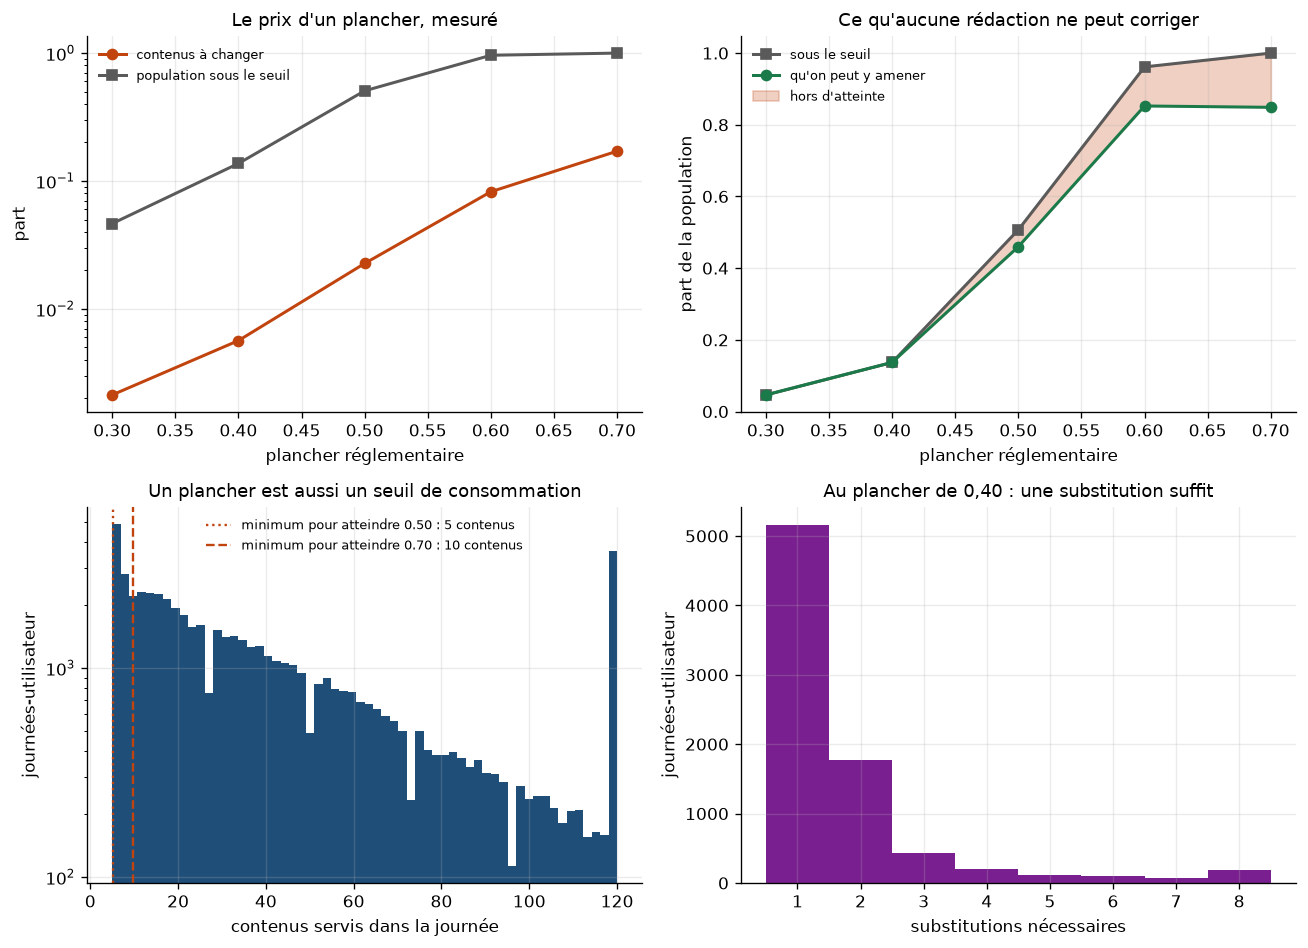

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
niveaux = sorted(prix)
ax.plot(niveaux, [prix[niveau]["dépense"] for niveau in niveaux], marker="o",
        color=PALETTE["disorder"], label="contenus à changer")
ax.plot(niveaux, [prix[niveau]["sous"] for niveau in niveaux], marker="s",
        color=PALETTE["neutral"], label="population sous le seuil")
ax.set(xlabel="plancher réglementaire", ylabel="part", yscale="log",
       title="Le prix d'un plancher, mesuré")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(niveaux, [prix[niveau]["sous"] for niveau in niveaux], marker="s",
        color=PALETTE["neutral"], label="sous le seuil")
ax.plot(niveaux, [prix[niveau]["traitée"] for niveau in niveaux], marker="o",
        color=PALETTE["remedy"], label="qu'on peut y amener")
ax.fill_between(niveaux, [prix[niveau]["traitée"] for niveau in niveaux],
                [prix[niveau]["sous"] for niveau in niveaux], color=PALETTE["disorder"],
                alpha=0.25, label="hors d'atteinte")
ax.set(xlabel="plancher réglementaire", ylabel="part de la population",
       title="Ce qu'aucune rédaction ne peut corriger")
ax.legend(fontsize=8)

ax = axes[1, 0]
lecture = np.repeat(servis, occurrences)
ax.hist(np.clip(lecture, 0, 120), bins=60, color=PALETTE["order"])
for niveau, style in ((0.50, ":"), (0.70, "--")):
    seuil = CATALOGUE ** niveau
    ax.axvline(seuil, color=PALETTE["disorder"], linestyle=style, linewidth=1.4,
               label=f"minimum pour atteindre {niveau:.2f} : {seuil:.0f} contenus")
ax.set(yscale="log", xlabel="contenus servis dans la journée", ylabel="journées-utilisateur",
       title="Un plancher est aussi un seuil de consommation")
ax.legend(fontsize=7.5)

ax = axes[1, 1]
sous_quarante = valeurs < 0.40
coûts_quarante = np.array([substitutions_to_floor(sections[ligne], CATALOGUE, 0.40) or 0
                           for ligne in np.flatnonzero(sous_quarante)], dtype=float)
ax.hist(np.repeat(np.clip(coûts_quarante, 0, 8), occurrences[sous_quarante]),
        bins=np.arange(0.5, 9.5), color=PALETTE["field"])
ax.set(xlabel="substitutions nécessaires", ylabel="journées-utilisateur",
       title="Au plancher de 0,40 : une substitution suffit")

save_figure(figure, "fig29_prix_du_plancher.png")
plt.show()

## 6. Ce que cela change

**Le plancher proposé par ce dépôt est décoratif.** Un contenu sur cent soixante-quinze, une
substitution médiane par journée traitée : à $0{,}40$ sur un catalogue de vingt-six rubriques, la
norme ne contraint rien. Le [chapitre 28](28_catalogue.md) avait montré que le niveau dépend du
catalogue ; celui-ci montre qu'au niveau choisi, il ne mord pas.

**Et la forme même de la grandeur réglementée est en cause.** Le [protocole](../ide.md) prescrit
la **part de la population sous le seuil**, précisément parce qu'« une moyenne satisfaisante peut
masquer une minorité entièrement enfermée ». Mais une part est un seuil, et un seuil s'atteint
par la marge : la plateforme la moins scrupuleuse traite les lecteurs *juste en dessous* et laisse
les autres où ils sont. La grandeur choisie contre le masquage par la moyenne invite au traitement
de la marge.

**Un plancher doit tenir compte du volume servi.** Au-dessus de $0{,}50$, une part croissante des
lecteurs est hors d'atteinte — non parce qu'ils sont enfermés, mais parce qu'ils lisent peu. Une
norme qui les compte comme non conformes pousse la plateforme à leur servir davantage. Deux issues
possibles, et il faut choisir : exempter les sessions courtes, ou normaliser l'indice par le
maximum atteignable plutôt que par $\log_2 k$.

**Réserves.** Le coût est mesuré en **contenus échangés**, pas en engagement : EB-NeRD ne fournit
aucun modèle de pertinence, et une substitution peut être indolore comme elle peut coûter cher.
Le calcul suppose en outre que **n'importe quelle rubrique peut être servie à n'importe qui**, ce
qui surestime la facilité — un journal n'a pas toujours l'article qu'il faudrait. Enfin, tout ceci
vaut pour le catalogue de vingt-six rubriques de ce corpus : à catalogue plus grossier, le
plancher mord encore moins.